# Binary cortical parcellation (fsaverage5-LH)           

Three anatomical tasks. Each method gets the same hyperparameter budget: bifiltration sweeps 28 channel pairs x 5 slopes x 2 cut strategies

Ward+connectivity sweeps the same 28 pairs

single-linkage runs on 8 raw channels. Primary metric is DICE

`stability` is the fraction of slopes on which bifiltration beats the best non-bif baseline by DICE.         

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import nibabel as nib
from nilearn.datasets import fetch_surf_fsaverage
from nilearn.surface import load_surf_mesh, load_surf_data
from nilearn.plotting import plot_surf_roi
import templateflow.api as tf

from scipy.sparse import csr_matrix, diags
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture

from mpc.filtration_builder import FiltrationBuilder
from mpc.clustering_utils import ClusteringUtils
from mpc.pipeline import run_bifiltration_edges

FIG = Path("figures")
FIG.mkdir(exist_ok=True)
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE) 

In [2]:
fs = fetch_surf_fsaverage(mesh="fsaverage5")
mesh_lh = load_surf_mesh(fs["pial_left"])
coords = np.asarray(mesh_lh.coordinates)
faces = np.asarray(mesh_lh.faces).astype(int)
curv = load_surf_data(fs["curv_left"]).astype(float)
sulc = load_surf_data(fs["sulc_left"]).astype(float)
thk = load_surf_data(fs["thick_left"]).astype(float)
N = len(coords)

dk_path = tf.get(template="fsaverage", hemi="L", density="10k",
                 atlas="Desikan2006", suffix="dseg", extension="label.gii")
dk_gii = nib.load(str(dk_path))
dk_labels = dk_gii.darrays[0].data.astype(int)
dk_names = {int(e.key): e.label for e in dk_gii.labeltable.labels}
ignore = {0}
cc = next((k for k, v in dk_names.items() if "corpus" in v.lower()), None)
if cc is not None:
    ignore.add(cc)


def _dk_ids(keywords):
    return {k for k, v in dk_names.items()
            if any(kw.lower() in v.lower() for kw in keywords)}


print(f"vertices = {N}, labels = {len(dk_names)}, ignored = {sorted(ignore)}")

vertices = 10242, labels = 36, ignored = [0, 4]


In [3]:
E_all = np.sort(
    np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]]),
    axis=1,
)
edges = np.unique(E_all, axis=0)
rr = np.r_[edges[:, 0], edges[:, 1]]
cc2 = np.r_[edges[:, 1], edges[:, 0]]
A = csr_matrix((np.ones(len(rr)), (rr, cc2)), shape=(N, N))
deg = np.asarray(A.sum(axis=1)).ravel()
L = diags(deg) - A
lap_curv = L @ curv
lap_sulc = L @ sulc
lap_thk = L @ thk


def _grad_mag(scalar):
    diff = np.abs(scalar[edges[:, 1]] - scalar[edges[:, 0]])
    elen = np.linalg.norm(coords[edges[:, 1]] - coords[edges[:, 0]], axis=1)
    rate = diff / (elen + 1e-9)
    s = (np.bincount(edges[:, 0], weights=rate, minlength=N)
         + np.bincount(edges[:, 1], weights=rate, minlength=N))
    c = (np.bincount(edges[:, 0], minlength=N)
         + np.bincount(edges[:, 1], minlength=N))
    return s / (c + 1e-9)


g_sulc = _grad_mag(sulc)
g_curv = _grad_mag(curv)
print(f"edges = {len(edges)}")

edges = 30720


In [10]:
SCALARS = {
    "curv": curv, "sulc": sulc, "thk": thk,
    "lap_curv": lap_curv, "lap_sulc": lap_sulc, "lap_thk": lap_thk,
    "g_sulc": g_sulc, "g_curv": g_curv,
}
FILT = {k: FiltrationBuilder.get_scalar_edge_filtration(v, edges)
        for k, v in SCALARS.items()}

from itertools import combinations
PAIRS = list(combinations(SCALARS.keys(), 2))
SLOPES_GRID = [0.25, 0.5, 1.0, 2.0, 4.0]


def evaluate(labels, gt):
    p = align_binary(labels, gt)
    d, _, _, _ = dice_tp_fp_fn(p, gt)
    return float(d)


def evaluate_prf(labels, gt):
    p = align_binary(labels, gt)
    d, tp, fp, fn = dice_tp_fp_fn(p, gt)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    return float(d), float(prec), float(rec), tp, fp, fn


def align_binary(pred, gt):
    mask = gt >= 0
    p_raw = pred[mask].astype(int)
    g = gt[mask].astype(int)
    u = np.unique(p_raw)
    if len(u) < 2:
        p = np.zeros_like(p_raw)
    else:
        p = (p_raw == u[-1]).astype(int)
        if np.mean(p == g) < 0.5:
            p = 1 - p
    out = np.zeros(len(pred), dtype=int)
    out[mask] = p
    return out


def confusion_map(p_aligned, gt):
    out = np.zeros_like(gt)
    g = np.where(gt < 0, 0, gt)
    out[(p_aligned == 1) & (g == 1)] = 1
    out[(p_aligned == 1) & (g == 0)] = 2
    out[(p_aligned == 0) & (g == 1)] = 3
    return out


def dice_tp_fp_fn(p_aligned, gt):
    g = np.where(gt < 0, 0, gt)
    tp = int(((p_aligned == 1) & (g == 1)).sum())
    fp = int(((p_aligned == 1) & (g == 0)).sum())
    fn = int(((p_aligned == 0) & (g == 1)).sum())
    denom = 2 * tp + fp + fn
    return ((2 * tp / denom) if denom > 0 else 0.0), tp, fp, fn


def ward_conn(f1, f2):
    return AgglomerativeClustering(
        n_clusters=2, linkage="ward", connectivity=A
    ).fit_predict(np.column_stack([f1, f2]))


def single_link(fname, min_size):
    lm = ClusteringUtils.get_linkage_matrix(FILT[fname], N)
    return ClusteringUtils.simplified_labels(
        lm, n_clusters=2, min_size=min_size, n_points=N,
    )


def kmeans_feat(f1, f2):
    return KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(
        np.column_stack([f1, f2]),
    )


def ward_no_conn(f1, f2):
    return AgglomerativeClustering(
        n_clusters=2, linkage="ward"
    ).fit_predict(np.column_stack([f1, f2]))


def gmm_feat(f1, f2):
    return GaussianMixture(
        n_components=2, covariance_type="full", random_state=0,
    ).fit_predict(np.column_stack([f1, f2]))


def spectral_feat(f1, f2):
    return SpectralClustering(
        n_clusters=2, affinity="nearest_neighbors",
        n_neighbors=10, random_state=0, assign_labels="kmeans",
    ).fit_predict(np.column_stack([f1, f2]))


In [12]:
BINARY_TASKS = [
    ("Sensorimotor",
     _dk_ids(["paracentral", "postcentral", "precentral"])),
    ("Pericalcarine (V1)", _dk_ids(["pericalcarine"])),
    ("Middle temporal", _dk_ids(["middletemporal"])),
]
for name, ids in BINARY_TASKS:
    assert ids, f"no DK labels matched for {name}"


def make_gt(ids):
    pos = np.isin(dk_labels, list(ids))
    bad = np.isin(dk_labels, list(ignore))
    return np.where(pos, 1, np.where(bad, -1, 0)).astype(int)


def run_task(ids):
    gt = make_gt(ids)
    n_pos = int((gt == 1).sum())
    min_size = max(5, min(N // 20, n_pos // 3))
    rows, labels_map = [], {}

    def _add(method, pair, kind, labels, slope=None):
        dice, prec, rec, tp, fp, fn = evaluate_prf(labels, gt)
        rows.append({"method": method, "pair": pair, "kind": kind,
                     "slope": slope, "DICE": dice, "prec": prec,
                     "rec": rec, "TP": tp, "FP": fp, "FN": fn})
        labels_map[method] = labels

    for a, b in PAIRS:
        _add(f"KMeans({a}+{b})", f"{a}x{b}", "cluster",
             kmeans_feat(SCALARS[a], SCALARS[b]))
        _add(f"Ward({a}x{b})", f"{a}x{b}", "cluster",
             ward_no_conn(SCALARS[a], SCALARS[b]))
        _add(f"GMM({a}+{b})", f"{a}x{b}", "cluster",
             gmm_feat(SCALARS[a], SCALARS[b]))
        _add(f"Spectral({a}x{b})", f"{a}x{b}", "cluster",
             spectral_feat(SCALARS[a], SCALARS[b]))

    for ch in SCALARS:
        _add(f"SL({ch})", ch, "SL", single_link(ch, min_size))

    for a, b in PAIRS:
        for meth in ("simplify", "persistence"):
            for slope in SLOPES_GRID:
                tag = f"Bif-{meth}({a}x{b})@s={slope}"
                r = run_bifiltration_edges(
                    N, FILT[a], FILT[b], method=meth,
                    n_clusters=2, min_size=min_size, slope=slope,
                )
                _add(tag, f"{a}x{b}", "bif", r.labels_combined, slope)

        _add(f"Ward+conn({a}x{b})", f"{a}x{b}", "ward",
             ward_conn(SCALARS[a], SCALARS[b]))

    return {"gt": gt, "rows": rows, "labels": labels_map,
            "min_size": min_size, "n_pos": n_pos}


RESULTS = {name: run_task(ids) for name, ids in BINARY_TASKS}
for name, res in RESULTS.items():
    print(f"{name:20s} n_pos={res['n_pos']:5d}"
          f"min_size={res['min_size']:4d} runs={len(res['rows'])}")


Sensorimotor         n_pos= 1470min_size= 490 runs=428
Pericalcarine (V1)   n_pos=  115min_size=  38 runs=428
Middle temporal      n_pos=  294min_size=  98 runs=428


In [13]:
def best_of(rows, kinds):
    pool = [r for r in rows if r["kind"] in kinds]
    return max(pool, key=lambda r: r["DICE"]) if pool else None


summary = []
for name, _ in BINARY_TASKS:
    rr = RESULTS[name]["rows"]
    bif = best_of(rr, {"bif"})
    ward = best_of(rr, {"ward"})
    sl = best_of(rr, {"SL"})
    cl = best_of(rr, {"cluster"})
    ref = max(
        [x for x in (ward, sl, cl) if x], key=lambda r: r["DICE"],
    )
    summary.append({
        "task": name,
        "best_pair": bif["pair"],
        "slope": bif["slope"],
        "DICE_bif": bif["DICE"],
        "prec_bif": bif["prec"],
        "rec_bif": bif["rec"],
        "DICE_ward_conn": ward["DICE"],
        "DICE_SL_best": sl["DICE"],
        "DICE_cluster_best": cl["DICE"],
        "cluster_method": cl["method"],
        "DICE_ref": ref["DICE"],
        "prec_ref": ref["prec"],
        "rec_ref": ref["rec"],
        "winner": "bif" if bif["DICE"] > ref["DICE"] else "baseline",
    })

SUM = pd.DataFrame(summary).set_index("task")
print(SUM.round(3).to_string())

                            best_pair  slope  DICE_bif  prec_bif  rec_bif  DICE_ward_conn  DICE_SL_best  DICE_cluster_best       cluster_method  DICE_ref  prec_ref  rec_ref winner
task                                                                                                                                                                               
Sensorimotor        lap_curvxlap_sulc   1.00     0.556     0.814    0.422           0.439         0.462              0.335  Ward(g_sulcxg_curv)     0.462     0.336    0.742    bif
Pericalcarine (V1)       thkxlap_curv   0.50     0.509     0.447    0.591           0.190         0.057              0.106        GMM(sulc+thk)     0.190     0.105    1.000    bif
Middle temporal       lap_sulcxg_sulc   0.25     0.458     0.852    0.313           0.223         0.225              0.094  GMM(lap_thk+g_sulc)     0.225     0.151    0.446    bif


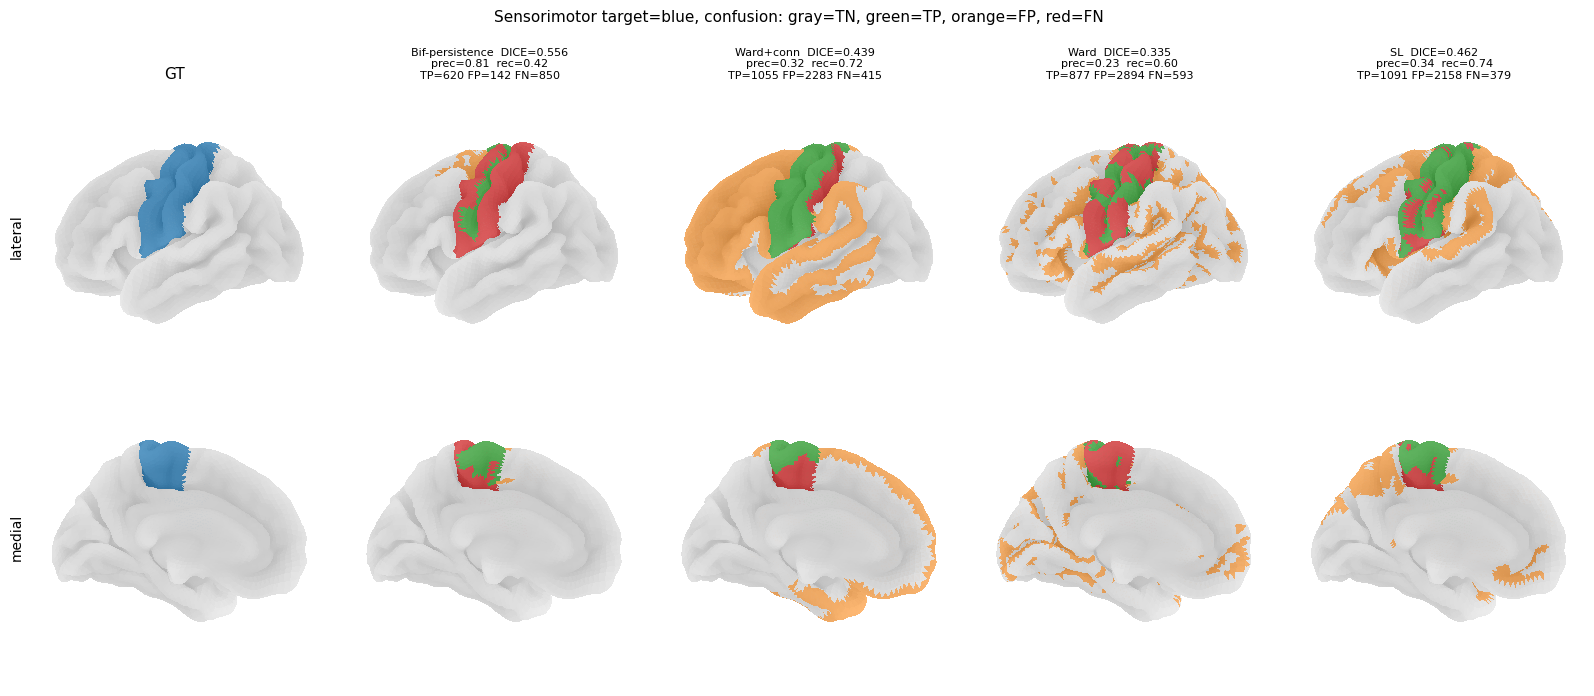

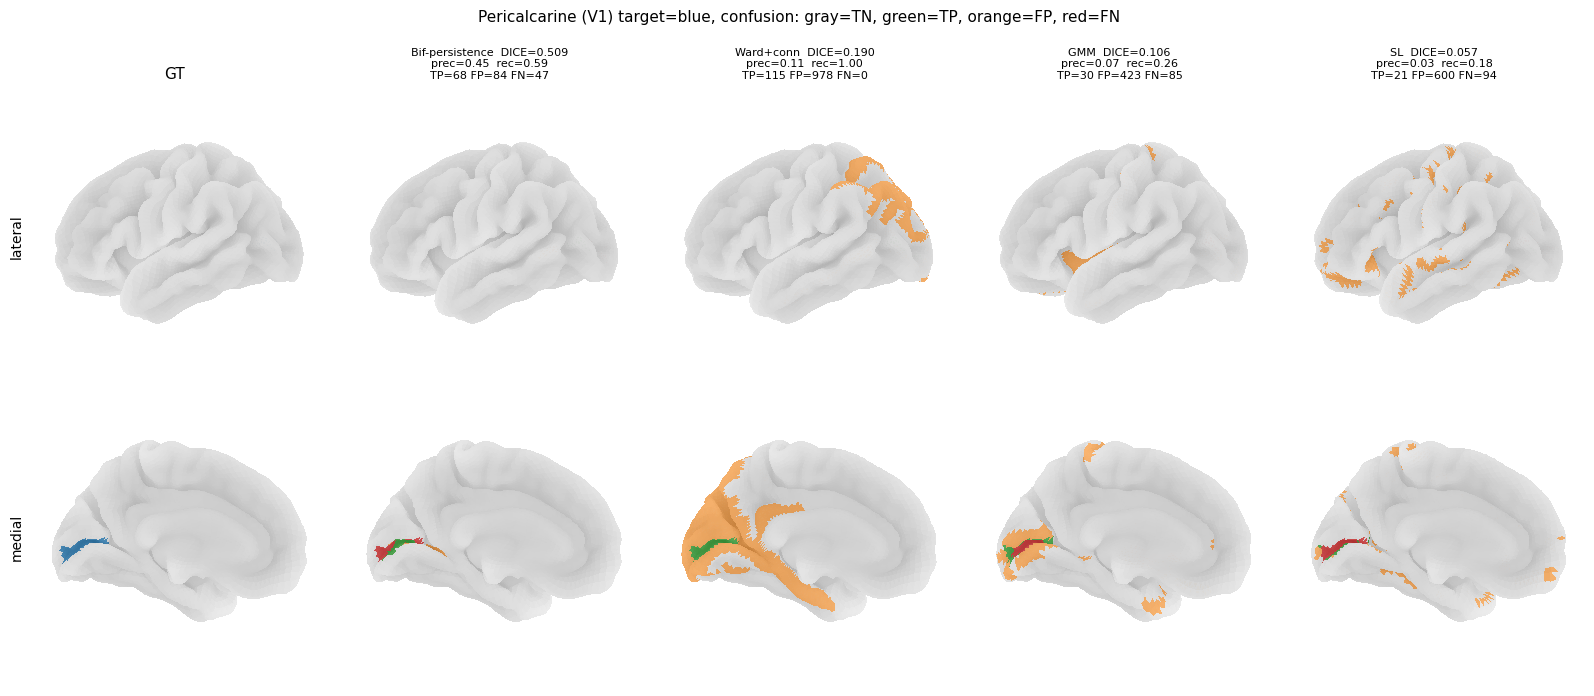

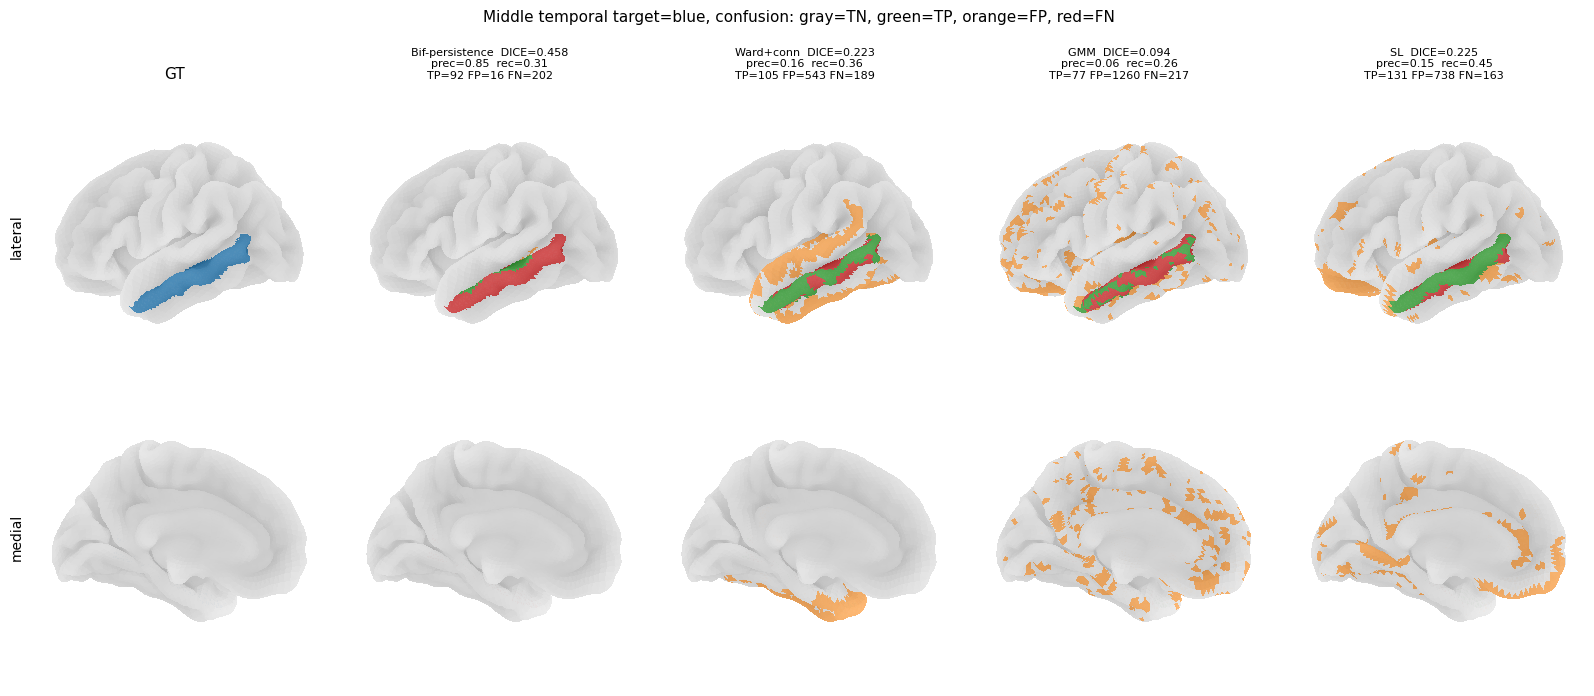

In [14]:
CMAP_GT = ListedColormap(["#e6e6e6", "#1f77b4"])
CMAP_CONF = ListedColormap(["#e6e6e6", "#2ca02c", "#ff9f40", "#d62728"])


def _plot(ax, values, cmap, vmax, view):
    plot_surf_roi(
        fs["pial_left"], roi_map=values, axes=ax,
        hemi="left", view=view, colorbar=False,
        bg_map=fs["sulc_left"], bg_on_data=True, alpha=0.9,
        cmap=cmap, vmin=0, vmax=vmax,
    )


def _method_panel(row_data, gt):
    p = align_binary(row_data["labels"], gt)
    c = confusion_map(p, gt)
    dice, tp, fp, fn = dice_tp_fp_fn(p, gt)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    short = row_data["method"].split("(")[0]
    title = (f"{short}  DICE={dice:.3f}\n"
             f"prec={prec:.2f}  rec={rec:.2f}\n"
             f"TP={tp} FP={fp} FN={fn}")
    return c, title


for name, _ in BINARY_TASKS:
    res = RESULTS[name]
    rr = res["rows"]
    gt = res["gt"]
    gt01 = np.where(gt < 0, 0, gt)

    panels = []
    panels.append(("GT", None, None))
    for kind, label in [("bif", "bif"), ("ward", "Ward+conn"),
                        ("cluster", "best cluster"),
                        ("SL", "best SL")]:
        row = best_of(rr, {kind})
        if row is None:
            continue
        row = dict(row); row["labels"] = res["labels"][row["method"]]
        c, ttl = _method_panel(row, gt)
        panels.append((label, c, ttl))

    NC = len(panels)
    fig, axes = plt.subplots(
        2, NC, figsize=(3.2 * NC, 7),
        subplot_kw={"projection": "3d"},
    )
    for row, view in enumerate(("lateral", "medial")):
        for j, (_, cmap_val, ttl) in enumerate(panels):
            if j == 0:
                _plot(axes[row, j], gt01, CMAP_GT, 1, view)
                if row == 0:
                    axes[row, j].set_title("GT", fontsize=11)
            else:
                _plot(axes[row, j], cmap_val, CMAP_CONF, 3, view)
                if row == 0:
                    axes[row, j].set_title(ttl, fontsize=8)
        axes[row, 0].text2D(
            -0.05, 0.5, view, transform=axes[row, 0].transAxes,
            fontsize=10, rotation=90, va="center",
        )

    fig.suptitle(
        f"{name} target=blue, confusion: gray=TN, green=TP, orange=FP, red=FN",
        fontsize=11, y=1.0,
    )
    fig.tight_layout()
    slug = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(FIG / f"brain_surface_confusion_{slug}.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


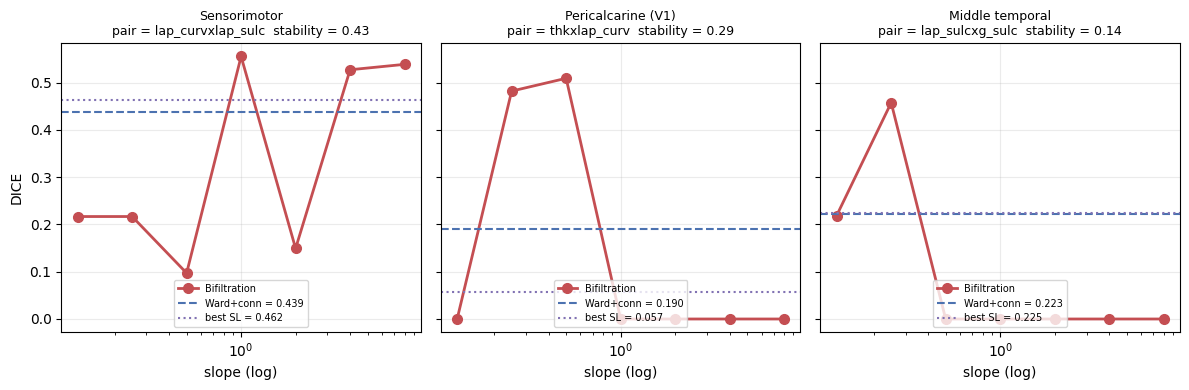

                            best_pair  slope  DICE_bif  prec_bif  rec_bif  DICE_ward_conn  DICE_SL_best  DICE_cluster_best       cluster_method  DICE_ref  prec_ref  rec_ref winner  stability
task                                                                                                                                                                                          
Sensorimotor        lap_curvxlap_sulc   1.00     0.556     0.814    0.422           0.439         0.462              0.335  Ward(g_sulcxg_curv)     0.462     0.336    0.742    bif      0.429
Pericalcarine (V1)       thkxlap_curv   0.50     0.509     0.447    0.591           0.190         0.057              0.106        GMM(sulc+thk)     0.190     0.105    1.000    bif      0.286
Middle temporal       lap_sulcxg_sulc   0.25     0.458     0.852    0.313           0.223         0.225              0.094  GMM(lap_thk+g_sulc)     0.225     0.151    0.446    bif      0.143


In [15]:
SLOPES = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]


def sweep_slope(task_name):
    res = RESULTS[task_name]
    rr = res["rows"]
    bif = best_of(rr, {"bif"})
    a, b = bif["pair"].split("x")
    meth = "simplify" if "simplify" in bif["method"] else "persistence"
    gt = res["gt"]
    dices = []
    for s in SLOPES:
        r = run_bifiltration_edges(
            N, FILT[a], FILT[b], method=meth,
            n_clusters=2, min_size=res["min_size"], slope=s,
        )
        dices.append(evaluate(r.labels_combined, gt))
    return {"slopes": SLOPES, "dices": dices, "pair": f"{a}x{b}",
            "ref_ward": best_of(rr, {"ward"})["DICE"],
            "ref_sl": best_of(rr, {"SL"})["DICE"]}


SWEEP = {name: sweep_slope(name) for name, _ in BINARY_TASKS}

fig, axes = plt.subplots(1, len(BINARY_TASKS), figsize=(4 * len(BINARY_TASKS), 4), sharey=True)
if len(BINARY_TASKS) == 1:
    axes = [axes]
for ax, (name, _) in zip(axes, BINARY_TASKS):
    sw = SWEEP[name]
    ref_max = max(sw["ref_ward"], sw["ref_sl"])
    stab = float(np.mean(np.array(sw["dices"]) > ref_max))
    ax.plot(sw["slopes"], sw["dices"], "o-", color="#C44E52",
            linewidth=2, markersize=7, label="Bifiltration")
    ax.axhline(sw["ref_ward"], linestyle="--", color="#4C72B0",
               label=f"Ward+conn = {sw['ref_ward']:.3f}")
    ax.axhline(sw["ref_sl"], linestyle=":", color="#8172B3",
               label=f"best SL = {sw['ref_sl']:.3f}")
    ax.set_xscale("log")
    ax.set_xlabel("slope (log)")
    ax.set_title(f"{name}\npair = {sw['pair']}  stability = {stab:.2f}",
                 fontsize=9)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="lower center")
axes[0].set_ylabel("DICE")
fig.tight_layout()
fig.savefig(FIG / "brain_surface_vineyard.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

SUM["stability"] = [
    float(np.mean(np.array(SWEEP[n]["dices"])
                  > max(SWEEP[n]["ref_ward"], SWEEP[n]["ref_sl"])))
    for n, _ in BINARY_TASKS
]
print(SUM.round(3).to_string())